In [2]:
# import stuff
import asymmetree.treeevolve as te
from asymmetree.visualization.tree_vis import visualize, assign_colors
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import graphviz_layout
from collections import defaultdict
import random
import matplotlib.gridspec as gridspec
from asymmetree.analysis.best_matches import lrt_from_tree
import numpy as np

import FunctionsTony

In [3]:
# set seed
# Setze den Seed für Pythons Standard-Zufallsfunktionen
random.seed(3)
# Setze den Seed für NumPys Zufallsfunktionen (wichtig für AsymmeTree)
np.random.seed(3)

# species tree
S = te.species_tree_n_age(
    4, 1.0, contraction_probability=0.0, contraction_proportion=0.2, contraction_bias="exponential"
)
# gene tree
T = te.dated_gene_tree(
    S, dupl_rate=1.0, loss_rate=0, hgt_rate=0.2, gc_rate=0.2, prohibit_extinction="per_species", dupl_polytomy=0.5
)
# prune all loss branches and the planted root
observable_gene_tree = te.prune_losses(T)

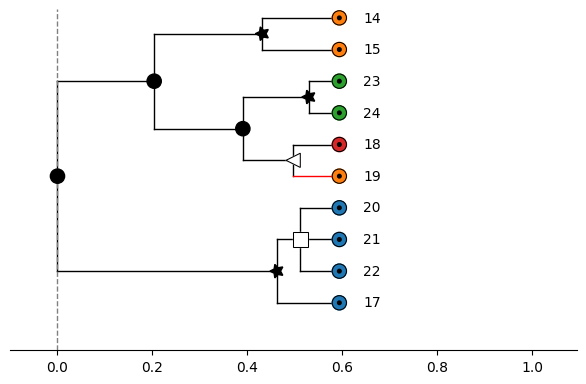

In [4]:
# get color dicts
species_colors, gene_colors = assign_colors(S, observable_gene_tree)
# visualize asymetree tree
visualize(observable_gene_tree, color_dict=gene_colors)

False

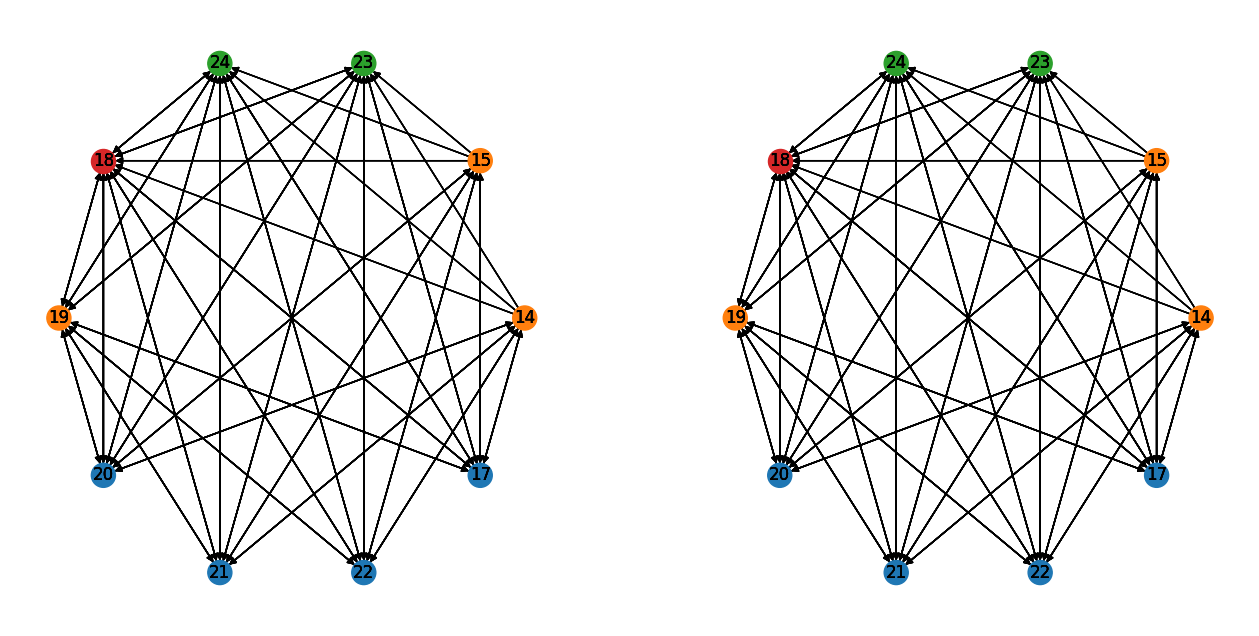

In [5]:
# convert to networkx
N = FunctionsTony.convert_to_nx(observable_gene_tree)

# Original BMG:
BMG = FunctionsTony.bmg(N)
BC = FunctionsTony.biccherry(BMG)
BMGBC = FunctionsTony.bmg(BC)

# reverse dict so every color has a list of leaves attached to it, for visualization
color_to_keys = defaultdict(list)
for key, color in gene_colors.items():
    color_to_keys[tuple(color)].append(key)

fig, axes = plt.subplots(1,2, figsize=(16, 8))

# Nach Tonys Funktion
for color, node_list in color_to_keys.items():
    nx.draw(BMG, nx.circular_layout(BMG), nodelist=node_list, node_color=[color] * len(node_list), ax=axes[0], with_labels=True)
# axes[1,0].set_title("Tree BMG Tony")
# network BMG
# axes[1,1].set_title("Network BMG Tony")
for color, node_list in color_to_keys.items():
    nx.draw(BMGBC, nx.circular_layout(BMGBC), nodelist=node_list, node_color=[color] * len(node_list), ax=axes[1], with_labels=True)
BMGBC == BMG

# network = insertHybrid.insertHybrid(N, 1)